📊 DATA INFORMATION
Train samples: 2256
Val samples: 432
Test samples: 595
Device: cpu
Example file: train\1 DOLLAR 10.npy
Example label: 1 DOLLAR
Max label: 101
Num classes: 102

🏷️ Label encoding complete: 102 classes

✅ DataLoaders created:
  Train batches: 282
  Val batches: 54
  Test batches: 75
Checking label range...
Train: 0 → 101
Val: 0 → 101
Test: 0 → 101
Num classes: 102

📐 Model Architecture:
  Input: 438 features x 120 frames
  Output: 102 classes
  Total parameters: 1,135,014

🚀 STARTING TRAINING


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 001/90 | Train Loss: 4.5582 | Train Acc: 0.0390 | Val Loss: 3.9686 | Val Acc: 0.1134
  ✅ Best model saved! (Val Acc: 0.1134)
Epoch 002/90 | Train Loss: 3.9498 | Train Acc: 0.0953 | Val Loss: 3.7154 | Val Acc: 0.1713
  ✅ Best model saved! (Val Acc: 0.1713)
Epoch 003/90 | Train Loss: 3.5772 | Train Acc: 0.1804 | Val Loss: 3.2962 | Val Acc: 0.2546
  ✅ Best model saved! (Val Acc: 0.2546)
Epoch 004/90 | Train Loss: 3.2951 | Train Acc: 0.2367 | Val Loss: 3.0488 | Val Acc: 0.3866
  ✅ Best model saved! (Val Acc: 0.3866)
Epoch 005/90 | Train Loss: 2.9897 | Train Acc: 0.3364 | Val Loss: 2.9555 | Val Acc: 0.3889
  ✅ Best model saved! (Val Acc: 0.3889)
Epoch 006/90 | Train Loss: 2.7735 | Train Acc: 0.3989 | Val Loss: 2.7442 | Val Acc: 0.4236
  ✅ Best model saved! (Val Acc: 0.4236)
Epoch 007/90 | Train Loss: 2.5929 | Train Acc: 0.4574 | Val Loss: 2.4970 | Val Acc: 0.5046
  ✅ Best model saved! (Val Acc: 0.5046)
Epoch 008/90 | Train Loss: 2.4210 | Train Acc: 0.5217 | Val Loss: 2.3413 | Val Acc:

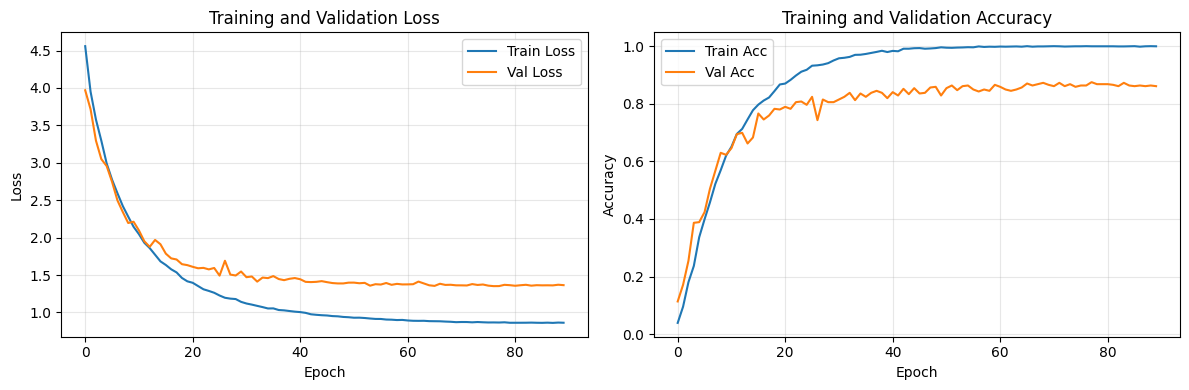

📊 Training curves saved to 'training_curves.png'

✅ TRAINING COMPLETE!


In [6]:
# ============================================================
# TCN FOR ASL LANDMARKS (TRAINING) - NO MASK
# Using Pre-split Data
# ============================================================
 
import numpy as np
from pathlib import Path
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
 
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
 
# ============================================================
# CONFIG
# ============================================================
 
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
 
TARGET_FRAMES = 120
FEATURE_DIM = 438
 
BATCH_SIZE = 8
EPOCHS = 90
LR = 3e-4
WEIGHT_DECAY = 1e-4
 
PATIENCE = 12
GRAD_CLIP = 1.0
LABEL_SMOOTH = 0.1
 
MODEL_SAVE_PATH = "tcn_best_model.pth"
LABEL_ENCODER_PATH = "label_encoder.npy"
 
# ============================================================
# LOAD DATA FROM CSV + NPY FILES
# ============================================================

import pandas as pd

DATA_ROOT = "/kaggle/input/datasets/mariamhany44/100-words-preprocessed-not-cleaned-no-mask/splits"

df = pd.read_csv(f"{DATA_ROOT}/splits.csv")

# Split
train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df   = df[df['split'] == 'val'].reset_index(drop=True)
test_df  = df[df['split'] == 'test'].reset_index(drop=True)

print("="*60)
print("📊 DATA INFORMATION")
print("="*60)
print(f"Train samples: {len(train_df)}")
print(f"Val samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")
print(f"Device: {DEVICE}")
print(f"Example file: {train_df.loc[0, 'filepath']}")
print(f"Example label: {train_df.loc[0, 'label']}")
 



# ============================================================
# CLEAN + ENCODE LABELS
# ============================================================

# 🔥 CLEAN LABELS FIRST
df['label'] = df['label'].str.strip()   # remove spaces
df['label'] = df['label'].str.replace(r"\s+", " ", regex=True)  # normalize spaces

# Split AFTER cleaning
train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df   = df[df['split'] == 'val'].reset_index(drop=True)
test_df  = df[df['split'] == 'test'].reset_index(drop=True)

# Encode
le = LabelEncoder()
le.fit(df['label'])

num_classes = len(le.classes_)

train_labels = le.transform(train_df['label'])
val_labels   = le.transform(val_df['label'])
test_labels  = le.transform(test_df['label'])

# 🔥 DEBUG CHECK
print("Max label:", train_labels.max())
print("Num classes:", num_classes)

assert train_labels.max() < num_classes
assert val_labels.max() < num_classes
assert test_labels.max() < num_classes

np.save(LABEL_ENCODER_PATH, le.classes_)

print(f"\n🏷️ Label encoding complete: {num_classes} classes")
# ============================================================
# DATASET CLASS (NO MASK)
# ============================================================
 
class ASLDataset(Dataset):
    def __init__(self, df, labels, root_dir):
        self.df = df
        self.labels = torch.from_numpy(labels).long()
        self.root_dir = Path(root_dir)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        relative_path = self.df.loc[idx, 'filepath'].replace("\\", "/")
        file_path = self.root_dir / relative_path
    
        x = np.load(file_path)
    
        if x.shape != (TARGET_FRAMES, FEATURE_DIM):
            x = np.resize(x, (TARGET_FRAMES, FEATURE_DIM))
    
        x = torch.from_numpy(x).float().transpose(0, 1)
        y = self.labels[idx]
    
        return x, y
 
# Create dataloaders
train_dataset = ASLDataset(train_df, train_labels, DATA_ROOT)
val_dataset   = ASLDataset(val_df, val_labels, DATA_ROOT)
test_dataset  = ASLDataset(test_df, test_labels, DATA_ROOT)
 
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
 
print(f"\n✅ DataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")
print("Checking label range...")

print("Train:", train_labels.min(), "→", train_labels.max())
print("Val:", val_labels.min(), "→", val_labels.max())
print("Test:", test_labels.min(), "→", test_labels.max())
print("Num classes:", num_classes)
# ============================================================
# MODEL DEFINITION (NO MASK)
# ============================================================
 
class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dilation):
        super().__init__()
        padding = dilation
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, 3, padding=padding, dilation=dilation),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.Conv1d(out_channels, out_channels, 3, padding=padding, dilation=dilation),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
        )
        self.res = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
 
    def forward(self, x):
        y = self.net(x)
        y = y[..., :x.size(2)]
        return y + self.res(x)
 
class TCN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        channels = [192, 192, 192, 192]
        layers = []
        for i, c in enumerate(channels):
            in_dim = input_dim if i == 0 else channels[i-1]
            layers.append(TemporalBlock(in_dim, c, dilation=2**i))
        self.tcn = nn.Sequential(*layers)
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(channels[-1], num_classes)
        self.dropout = nn.Dropout(0.3)
    def forward(self, x):
        """
        x: (batch, features, time)
        """
        x = self.tcn(x)                    # (batch, channels, time)
        x = self.global_avg_pool(x)        # (batch, channels, 1)
        x = x.squeeze(-1)                  # (batch, channels)
        x = self.dropout(x)
        return self.fc(x)                  # (batch, num_classes)
 
model = TCN(input_dim=FEATURE_DIM, num_classes=num_classes).to(DEVICE)
 
print(f"\n📐 Model Architecture:")
print(f"  Input: {FEATURE_DIM} features x {TARGET_FRAMES} frames")
print(f"  Output: {num_classes} classes")
print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")
 
# ============================================================
# LOSS FUNCTION WITH CLASS WEIGHTS
# ============================================================
 
# Get all possible classes
all_classes = np.arange(num_classes)

# Classes that actually appear in training
present_classes = np.unique(train_labels)

# Initialize all weights = 1.0
class_weights = np.ones(num_classes, dtype=np.float32)

# Compute weights only for present classes
computed_weights = compute_class_weight(
    class_weight='balanced',
    classes=present_classes,
    y=train_labels
)

# Assign computed weights
class_weights[present_classes] = computed_weights

# Convert to tensor
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
 
class SmoothCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1, weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.weight = weight
    def forward(self, logits, targets):
        n_classes = logits.size(1)
        with torch.no_grad():
            true_dist = torch.zeros_like(logits)
            true_dist.fill_(self.smoothing / (n_classes - 1))
            true_dist.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        log_probs = torch.log_softmax(logits, dim=1)
        if self.weight is not None:
            weight = self.weight[targets]
            loss = -(true_dist * log_probs).sum(dim=1) * weight
        else:
            loss = -(true_dist * log_probs).sum(dim=1)
        return loss.mean()
 
criterion = SmoothCrossEntropy(smoothing=LABEL_SMOOTH, weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)
 
# ============================================================
# TRAINING FUNCTION
# ============================================================
 
def train_one_epoch(loader):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        total_loss += loss.item() * y.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total
 
def evaluate(loader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            outputs = model(x)
            loss = criterion(outputs, y)
            total_loss += loss.item() * y.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(y).sum().item()
            total += y.size(0)
    return total_loss / total, correct / total
 
# ============================================================
# TRAINING LOOP
# ============================================================
 
print("\n" + "="*60)
print("🚀 STARTING TRAINING")
print("="*60)
 
best_val_acc = 0
patience_counter = 0
train_losses = []
val_losses = []
train_accs = []
val_accs = []
 
for epoch in range(EPOCHS):
    # Train
    train_loss, train_acc = train_one_epoch(train_loader)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    # Validate
    val_loss, val_acc = evaluate(val_loader)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    # Update scheduler
    scheduler.step()
    # Print progress
    print(f"Epoch {epoch+1:03d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
        }, MODEL_SAVE_PATH)
        print(f"  ✅ Best model saved! (Val Acc: {val_acc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⏹️ Early stopping at epoch {epoch+1}")
            break
 
# ============================================================
# FINAL EVALUATION
# ============================================================
 
print("\n" + "="*60)
print("📊 FINAL EVALUATION")
print("="*60)
 
# Load best model
checkpoint = torch.load(MODEL_SAVE_PATH)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1} with Val Acc: {checkpoint['val_acc']:.4f}")
 
# Test evaluation
test_loss, test_acc = evaluate(test_loader)
print(f"\n🎯 Test Set Results:")
print(f"  Test Loss: {test_loss:.4f}")
print(f"  Test Accuracy: {test_acc:.4f}")
 
# Per-class accuracy
def per_class_accuracy(loader, model, num_classes):
    model.eval()
    class_correct = torch.zeros(num_classes)
    class_total = torch.zeros(num_classes)
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            outputs = model(x)
            _, predicted = outputs.max(1)
            for i in range(len(y)):
                label = y[i]
                class_correct[label] += (predicted[i] == label).item()
                class_total[label] += 1
    return class_correct / (class_total + 1e-6)
 
per_class_acc = per_class_accuracy(test_loader, model, num_classes)
print(f"\n📈 Per-class accuracy (first 10 classes):")
for i in range(min(10, num_classes)):
    print(f"  Class {le.classes_[i]}: {per_class_acc[i]:.4f}")
 
# ============================================================
# SAVE TRAINING HISTORY
# ============================================================
 
import pickle
 
history = {
    'train_losses': train_losses,
    'val_losses': val_losses,
    'train_accs': train_accs,
    'val_accs': val_accs,
    'best_val_acc': best_val_acc,
    'test_acc': test_acc,
    'num_classes': num_classes,
    'target_frames': TARGET_FRAMES,
    'feature_dim': FEATURE_DIM
}
 
with open('training_history.pkl', 'wb') as f:
    pickle.dump(history, f)
 
print(f"\n💾 Training history saved to 'training_history.pkl'")
print(f"💾 Best model saved to {MODEL_SAVE_PATH}")
print(f"💾 Label encoder saved to {LABEL_ENCODER_PATH}")
 
# ============================================================
# PLOT TRAINING CURVES
# ============================================================
 
try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    # Loss plot
    axes[0].plot(train_losses, label='Train Loss')
    axes[0].plot(val_losses, label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    # Accuracy plot
    axes[1].plot(train_accs, label='Train Acc')
    axes[1].plot(val_accs, label='Val Acc')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150)
    plt.show()
    print("📊 Training curves saved to 'training_curves.png'")
except Exception as e:
    print(f"⚠️ Could not plot: {e}")
 
print("\n" + "="*60)
print("✅ TRAINING COMPLETE!")
print("="*60)